# 10 — Waterfall Chart
**When to use:** Show cumulative drop through a funnel, or how individual components add up/subtract from a total.

Matplotlib has no built-in waterfall — you build it with stacked bars. The trick is making invisible "spacer" bars to float the visible bars at the right height.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

STEPS  = ['visita_landing','inicio_solicitud','datos_personales','otp',
           'carga_documentos','aprobacion','activacion_tarjeta']
LABELS = ['Visits','Start','Personal','OTP','Docs','Approved','Activated']

totals = df[STEPS].sum().values
print('Funnel totals:', totals)

Funnel totals: [284774 101667  76089  52498  25106  11645   6337]


## 1. Funnel waterfall — absolute drop per step

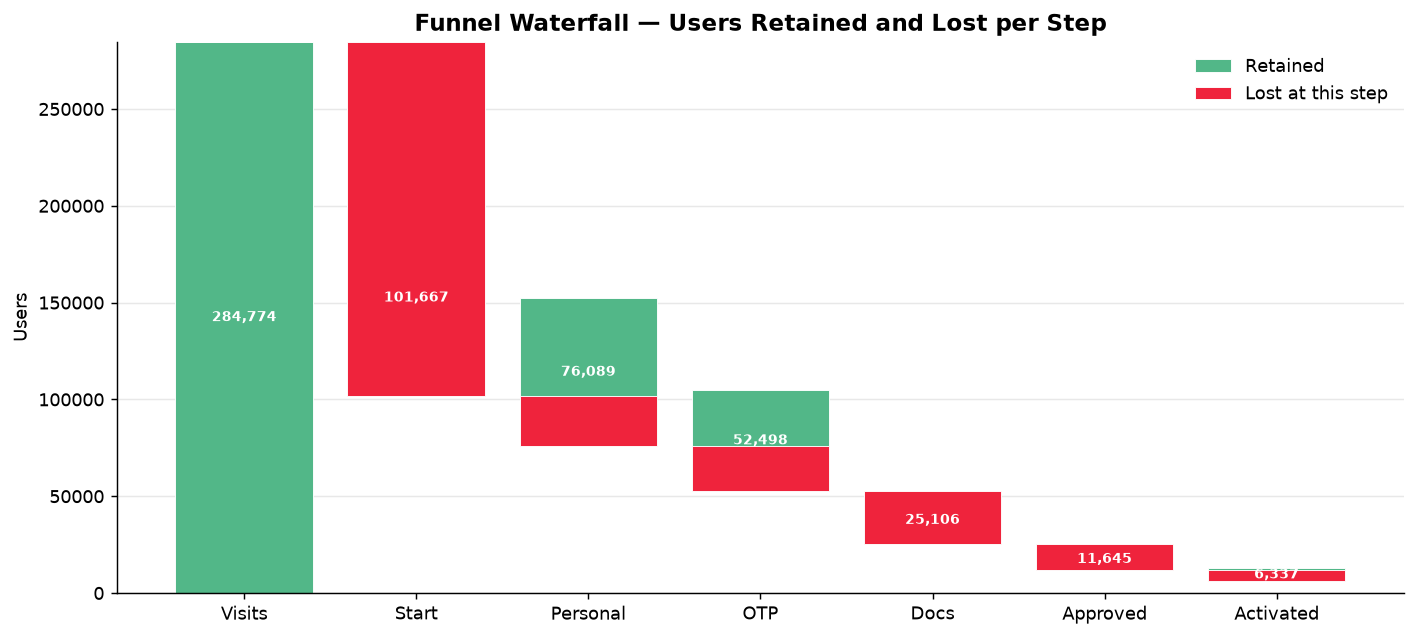

In [2]:
# Compute what's retained and what's lost at each step
retained = totals.copy().astype(float)
lost     = np.zeros(len(totals))
bottoms  = np.zeros(len(totals))    # where each bar starts (the invisible spacer height)

for i in range(1, len(totals)):
    lost[i]    = totals[i-1] - totals[i]    # users lost at this step
    bottoms[i] = totals[i]                  # retained bar starts at the bottom

fig, ax = plt.subplots(figsize=(11, 5), dpi=130)

# Invisible spacer bar — positions the retained bar at the right height
# color='none' makes it invisible
ax.bar(LABELS, bottoms, color='none')

# Retained (green)
bars_retained = ax.bar(LABELS, retained, bottom=bottoms,
                        color='#52b788', edgecolor='white', linewidth=0.5,
                        label='Retained')

# Lost (red) — stacked on top of retained
bars_lost = ax.bar(LABELS, lost, bottom=retained,
                    color='#ef233c', edgecolor='white', linewidth=0.5,
                    label='Lost at this step')

# Value labels
for i, (ret, bot, lss) in enumerate(zip(retained, bottoms, lost)):
    # Retained count
    ax.text(i, bot + ret/2, f'{int(ret):,}',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    # Lost count (only where there's a loss)
    if lss > 0:
        ax.text(i, ret + lss/2 + bot, f'-{int(lss):,}',
                ha='center', va='center', fontsize=7.5, color='white')

ax.set_title('Funnel Waterfall — Users Retained and Lost per Step',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Users')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/10_waterfall_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Revenue waterfall — contributions and deductions
A classic use case: starting revenue, add upsells, subtract refunds and churn, arrive at net revenue.

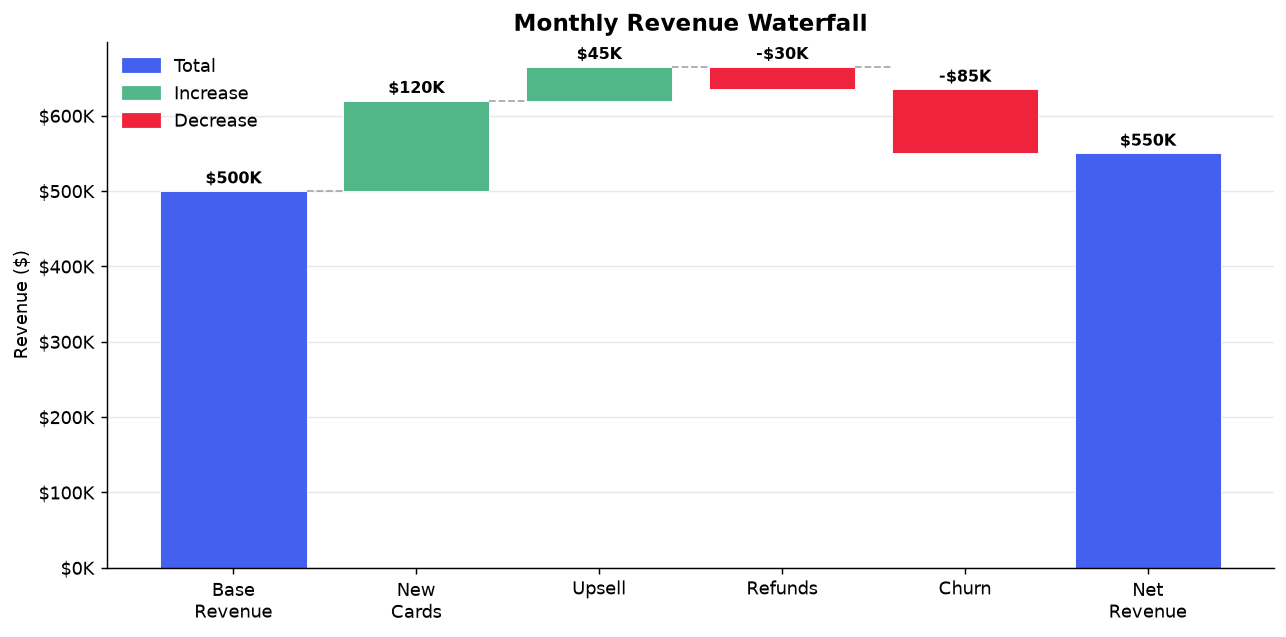

In [3]:
# Simulate a monthly revenue waterfall
items  = ['Base\nRevenue', 'New\nCards', 'Upsell', 'Refunds', 'Churn', 'Net\nRevenue']
values = [500_000, 120_000, 45_000, -30_000, -85_000, None]  # None = computed total

# Compute running total and final value
running = 0
starts  = []
heights = []
colors  = []

for i, (item, val) in enumerate(zip(items, values)):
    if i == 0:               # first bar starts at 0
        starts.append(0)
        heights.append(val)
        colors.append('#4361ee')
        running = val
    elif val is None:        # last bar = total, starts at 0
        starts.append(0)
        heights.append(running)
        colors.append('#4361ee')
    elif val >= 0:           # positive: bar starts at current running total
        starts.append(running)
        heights.append(val)
        colors.append('#52b788')
        running += val
    else:                    # negative: bar starts at running - |val|
        starts.append(running + val)
        heights.append(-val)  # bar height is positive
        colors.append('#ef233c')
        running += val

fig, ax = plt.subplots(figsize=(10, 5), dpi=130)

ax.bar(items, heights, bottom=starts, color=colors, edgecolor='white', linewidth=0.5)

# Value labels
for i, (start, height, item) in enumerate(zip(starts, heights, items)):
    val = values[i] if values[i] is not None else running
    label = f'${abs(val)/1000:.0f}K' if val >= 0 else f'-${abs(val)/1000:.0f}K'
    ax.text(i, start + height + 5000, label,
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Connector lines between bars
for i in range(len(items) - 2):  # skip last bar
    end_of_bar = starts[i] + heights[i]
    ax.plot([i + 0.4, i + 0.6], [end_of_bar, end_of_bar],
            color='#aaa', linewidth=1, linestyle='--')

# Legend
legend_items = [
    mpatches.Patch(color='#4361ee', label='Total'),
    mpatches.Patch(color='#52b788', label='Increase'),
    mpatches.Patch(color='#ef233c', label='Decrease'),
]
ax.legend(handles=legend_items, frameon=False)

ax.set_title('Monthly Revenue Waterfall', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/10_waterfall_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
| Concept | Key point |
|---|---|
| **How it works** | Stacked bars with invisible spacers (`color='none'`) |
| **Retained/lost** | Green bars for kept users, red for lost |
| **Connector lines** | `ax.plot([x1,x2],[y,y])` between bars |
| **Best for** | Funnel drop-off, P&L, revenue decomposition |

**Next:** `11_bump_chart.ipynb`